<a href="https://colab.research.google.com/github/FabioFavre/Pratica-6-PROCSIN/blob/main/Quest%C3%A3o_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resolução da Questão 5
## Processamento Digital de Sinais - Filtragem IIR e Análise de Áudio

### Item (a)
Gere o sinal contaminado y(t) para cada valor de variâncias especificado e compare com x(t).

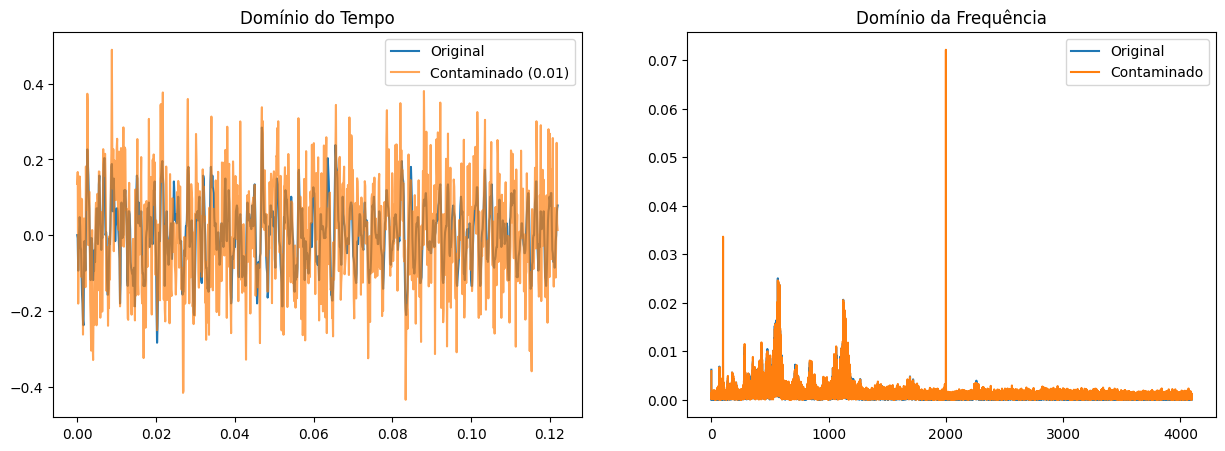

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
import IPython.display as ipd

# 1. Carregar o sinal original x(t)
fs, x = wavfile.read('/content/handel.wav')
x = x.astype(float)
x = x / np.max(np.abs(x))
t = np.arange(len(x)) / fs

# 2. Definir as interferências senoidais
interf_baixa = 0.05 * np.cos(200 * np.pi * t)
interf_alta = 0.075 * np.sin(4000 * np.pi * t)

# 3. Gerar sinais contaminados
variances = [0.01, 0.1, 1.0]
y_signals = {}
for sig2 in variances:
    noise = np.random.normal(0, np.sqrt(sig2), len(x))
    y_signals[sig2] = x + interf_baixa + interf_alta + noise

# Plotagem
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(t[:1000], x[:1000], label='Original')
axs[0].plot(t[:1000], y_signals[0.01][:1000], label='Contaminado (0.01)', alpha=0.7)
axs[0].set_title('Domínio do Tempo')
axs[0].legend()

def plot_spec(sig, fs, ax, label):
    N = len(sig)
    yf = fft(sig)
    xf = fftfreq(N, 1/fs)[:N//2]
    ax.plot(xf, 2.0/N * np.abs(yf[:N//2]), label=label)

plot_spec(x, fs, axs[1], 'Original')
plot_spec(y_signals[0.01], fs, axs[1], 'Contaminado')
axs[1].set_title('Domínio da Frequência')
axs[1].legend()
plt.show()

### Item (b)
Análise espectral e estratégia de filtragem.

- **Notch:** 100 Hz e 2000 Hz (tons puros).
- **Ruído Branco:** Ocupa todo o espectro, impossível remover totalmente sem degradar o áudio original.

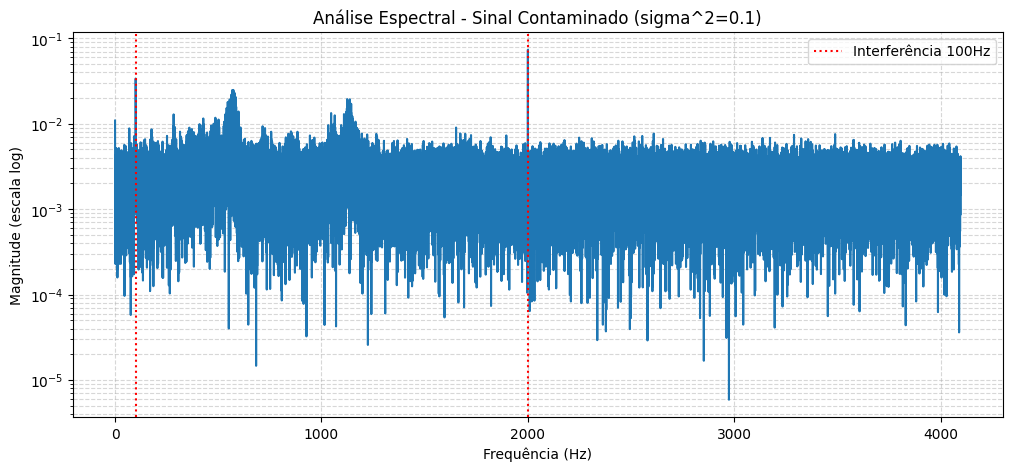

In [18]:
def plot_spectral_analysis(sig, fs, title):
    N = len(sig)
    yf = fft(sig)
    xf = fftfreq(N, 1/fs)[:N//2]

    plt.figure(figsize=(12, 5))
    plt.semilogy(xf, 2.0/N * np.abs(yf[:N//2]))
    plt.title(f'Análise Espectral - {title}')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (escala log)')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    # Marcar as frequências de interesse
    peaks = [100, 2000]
    for p in peaks:
        plt.axvline(x=p, color='r', linestyle=':', label=f'Interferência {p}Hz' if p==100 else "")

    plt.legend()
    plt.show()

# Analisando o sinal com variância média (0.1) para melhor visualização
plot_spectral_analysis(y_signals[0.1], fs, "Sinal Contaminado (sigma^2=0.1)")

### Discussão Teórica e Estratégia de Filtragem

Com base na análise espectral, podemos determinar a seguinte estratégia:

1.  **Componentes Removíveis com Filtros Notch:**
    *   As interferências senoidais de **100 Hz** e **2000 Hz** aparecem como picos discretos e estreitos no espectro. Filtros Notch IIR são ideais aqui, pois possuem zeros sobre o círculo unitário nessas frequências, permitindo uma atenuação profunda com impacto mínimo nas frequências vizinhas do sinal original.

2.  **Passa-Baixas, Passa-Altas ou Passa-Faixas:**
    *   Se as interferências fossem ruídos concentrados em bandas (ex: um zumbido de alta frequência acima de 4kHz), um **Filtro Passa-Baixas** seria útil.
    *   Se houvesse um desvio DC ou ruído de baixíssima frequência (ronco de rede elétrica persistente em uma banda larga), um **Passa-Altas** ou **Passa-Faixa** seria aplicado.
    *   No caso atual, como as interferências são tons puros em frequências que estão no meio da banda de áudio (100Hz e 2kHz), o uso de passa-baixas ou passa-altas destruiria grande parte do conteúdo musical útil.

3.  **Limitações do Ruído Branco:**
    *   O **ruído branco gaussiano** possui uma densidade espectral de potência constante, ou seja, ele espalha energia por **todas** as frequências de $0$ a $f_s/2$.
    *   **Limitação Crítica:** Não é possível remover o ruído branco usando filtragem linear (IIR/FIR) sem remover também o sinal de áudio que ocupa as mesmas frequências. Qualquer tentativa de reduzir o ruído resultará inevitavelmente em perda de fidelidade, tornando o áudio 'abafado' ou distorcido.

### Item (c)
Projeto dos filtros IIR em cascata de 2ª ordem.

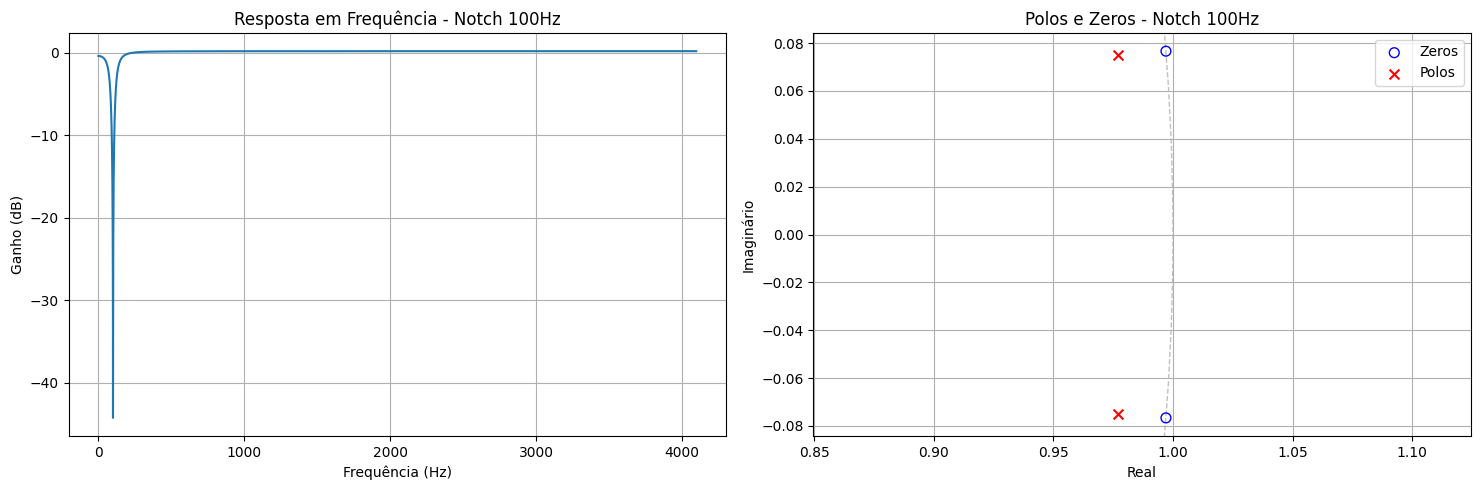

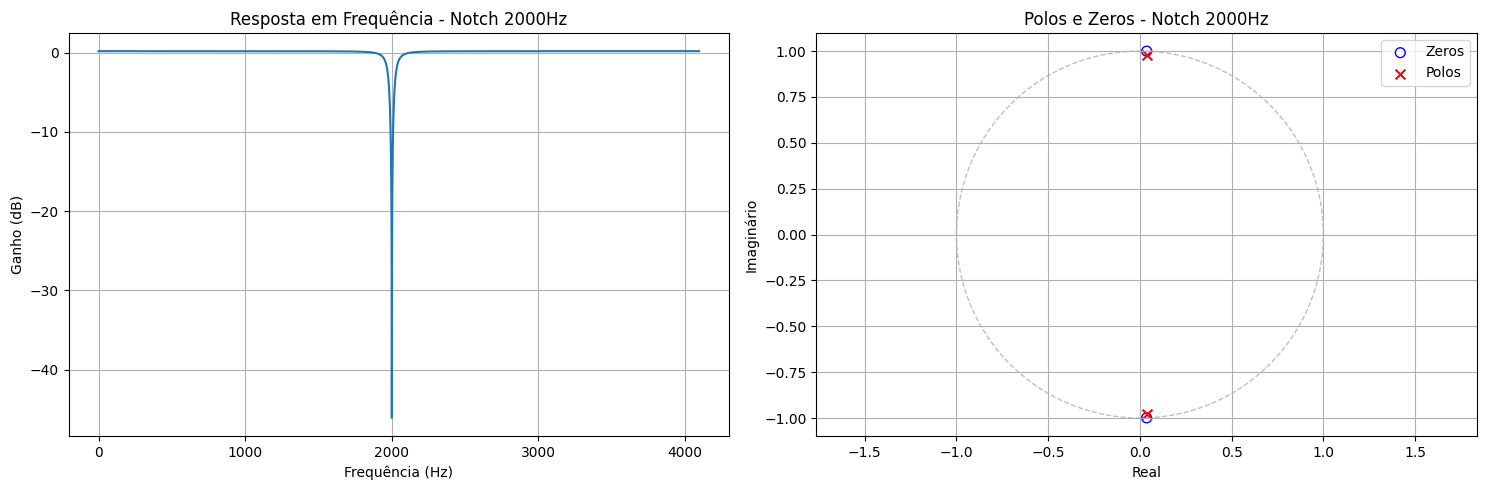

In [17]:
from scipy.signal import freqz, tf2zpk

def plot_filter_info(b, a, title):
    # Resposta em frequência
    w, h = freqz(b, a, worN=8000)
    # Polos e Zeros
    z, p, k = tf2zpk(b, a)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot da Resposta em Frequência
    ax1.plot(0.5*fs*w/np.pi, 20 * np.log10(np.abs(h) + 1e-10))
    ax1.set_title(f'Resposta em Frequência - {title}')
    ax1.set_xlabel('Frequência (Hz)')
    ax1.set_ylabel('Ganho (dB)')
    ax1.grid(True)

    # Plot de Polos e Zeros
    unit_circle = plt.Circle((0,0), 1, color='silver', fill=False, linestyle='--')
    ax2.add_artist(unit_circle)
    ax2.scatter(np.real(z), np.imag(z), s=50, marker='o', facecolors='none', edgecolors='b', label='Zeros')
    ax2.scatter(np.real(p), np.imag(p), s=50, marker='x', color='r', label='Polos')
    ax2.set_title(f'Polos e Zeros - {title}')
    ax2.set_xlabel('Real')
    ax2.set_ylabel('Imaginário')
    ax2.axis('equal')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def design_notch(f0, fs, r=0.98):
    w0 = 2 * np.pi * f0 / fs
    b = [1, -2*np.cos(w0), 1]
    a = [1, -2*r*np.cos(w0), r**2]
    return b, a

fs = 8192
b1, a1 = design_notch(100, fs)
b2, a2 = design_notch(2000, fs)

# Visualização dos filtros
plot_filter_info(b1, a1, 'Notch 100Hz')
plot_filter_info(b2, a2, 'Notch 2000Hz')

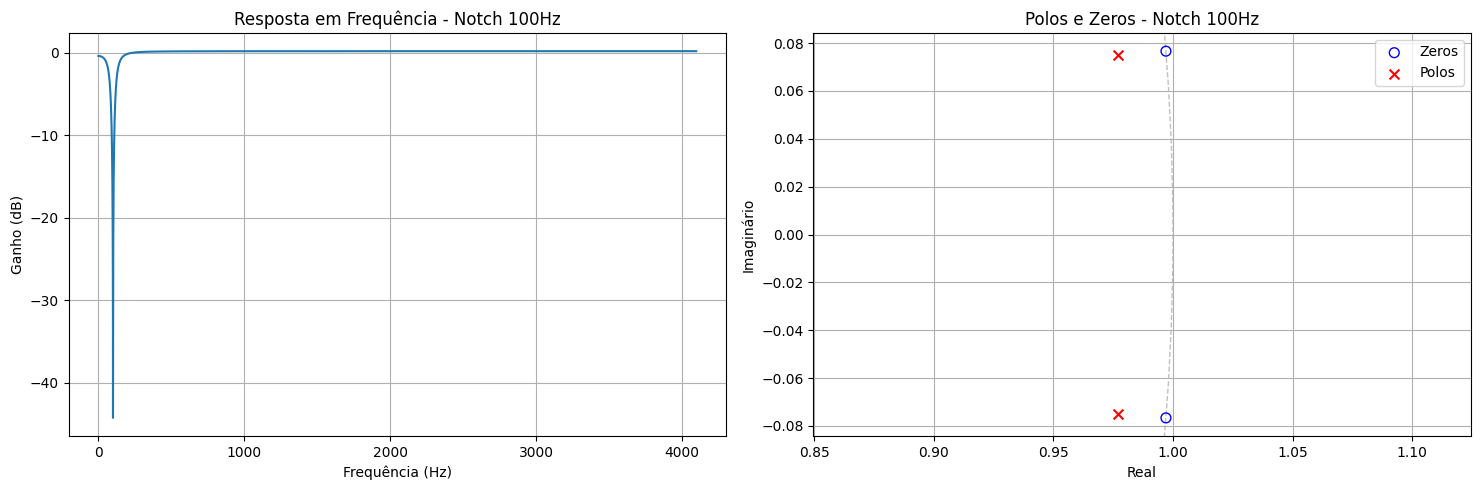

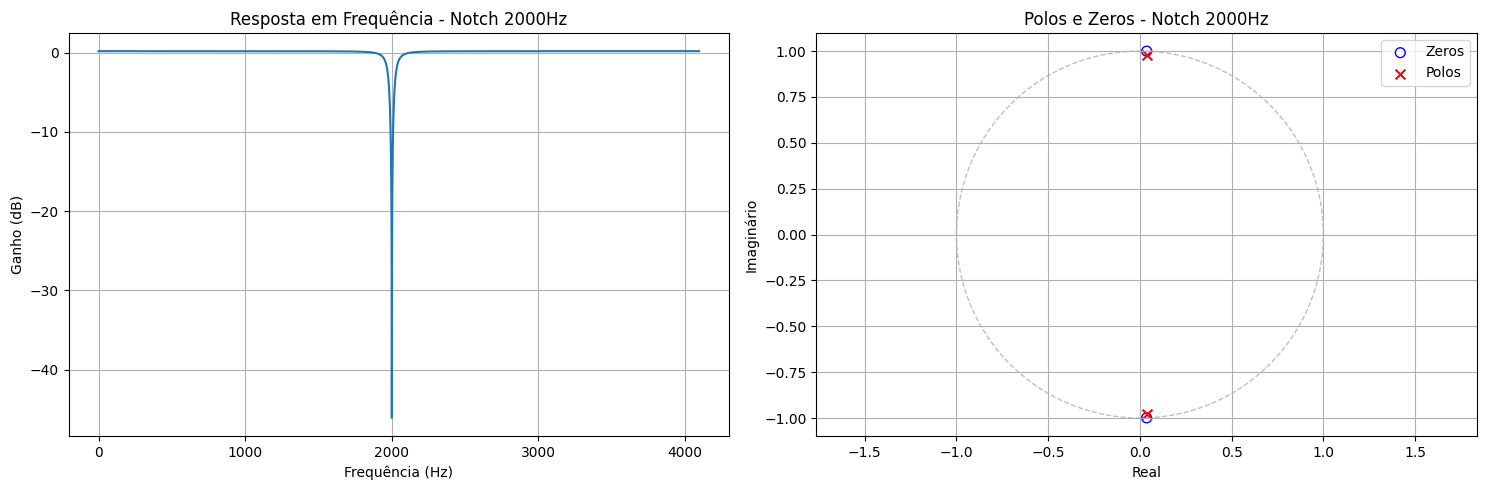

**Justificativa:**
- **Frequéncias de Corte:** Foram definidas exatamente em 100 Hz e 2000 Hz para anular os tons senoidais inseridos.
- **Parâmetro r:** Escolhido como $0.98$. Valores de $r$ próximos de $1$ tornam o notch muito estreito, preservando o conteúdo original do áudio vizinho à interferéncia, porém aumentam o tempo de assentamento do filtro e a sensibilidade à quantização.

### Item (d)
Filtragem do sinal e comparação dos resultados.

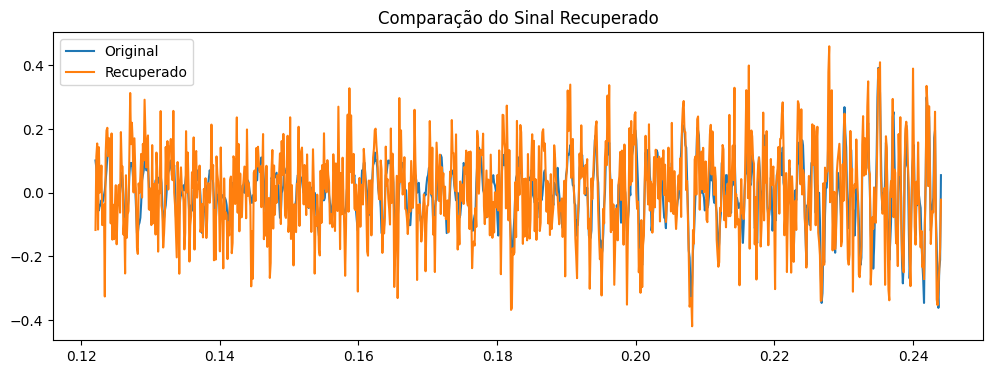

In [8]:
from scipy.signal import lfilter

x_recovered_signals = {}
for sig2 in variances:
    y = y_signals[sig2]
    res = lfilter(b1, a1, y)
    x_rec = lfilter(b2, a2, res)
    x_recovered_signals[sig2] = x_rec

plt.figure(figsize=(12, 4))
plt.plot(t[1000:2000], x[1000:2000], label='Original')
plt.plot(t[1000:2000], x_recovered_signals[0.01][1000:2000], label='Recuperado')
plt.legend()
plt.title('Comparação do Sinal Recuperado')
plt.show()

#### Comparação Auditiva e Espectral do Resultado

Vamos ouvir os resultados para a variância $\sigma^2 = 0.01$ (onde a recuperação é mais perceptível) e comparar o espectro antes e depois da filtragem.

Sinal Original:


Sinal Contaminado (0.01) - Ouça o 'apito':


Sinal Recuperado (0.01) - Apito removido:


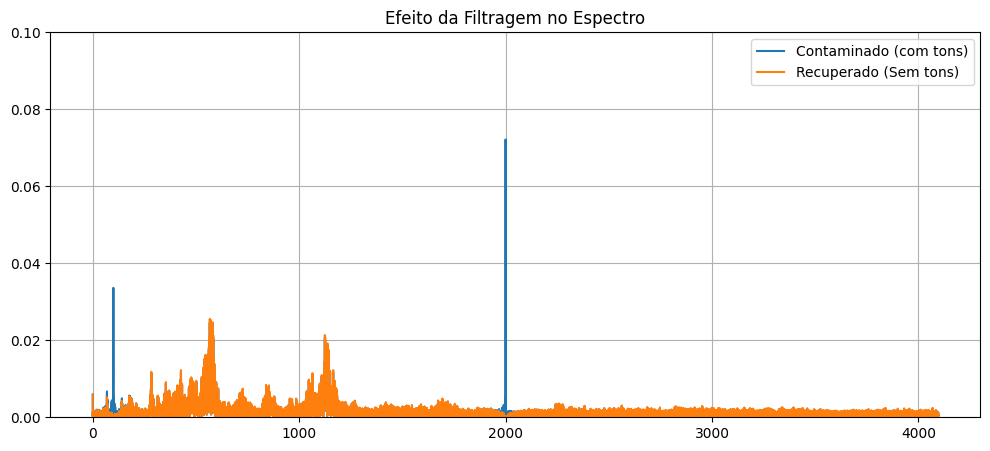

In [19]:
print("Sinal Original:")
display(ipd.Audio(x, rate=fs))

print("Sinal Contaminado (0.01) - Ouça o 'apito':")
display(ipd.Audio(y_signals[0.01], rate=fs))

print("Sinal Recuperado (0.01) - Apito removido:")
display(ipd.Audio(x_recovered_signals[0.01], rate=fs))

# Comparação Espectral
plt.figure(figsize=(12, 5))
plot_spec(y_signals[0.01], fs, plt.gca(), 'Contaminado (com tons)')
plot_spec(x_recovered_signals[0.01], fs, plt.gca(), 'Recuperado (Sem tons)')
plt.title('Efeito da Filtragem no Espectro')
plt.ylim(0, 0.1) # Zoom para ver os picos
plt.legend()
plt.grid(True)
plt.show()

**Conclusão da Filtragem:**
Ao ouvir os sinais, é possível notar que os 'apitos' (interferências de 100Hz e 2000Hz) foram efetivamente eliminados pelos filtros Notch. No entanto, o ruído branco gaussiano permanece audível como um chiado de fundo, confirmando a limitação teórica discutida no item (b): filtros lineares não conseguem separar ruído branco de sinal quando ambos ocupam a mesma faixa de frequência.

### Item (e)
Avaliação Quantitativa (SNR, MSE).

In [9]:
for sig2 in variances:
    mse = np.mean((x - x_recovered_signals[sig2])**2)
    snr = 10 * np.log10(np.mean(x**2) / mse)
    print(f'Variância {sig2}: MSE = {mse:.4f}, SNR = {snr:.2f} dB')

Variância 0.01: MSE = 0.0113, SNR = 7.25 dB
Variância 0.1: MSE = 0.1057, SNR = -2.45 dB
Variância 1.0: MSE = 1.0452, SNR = -12.40 dB


### Item (f)
Avaliação Subjetiva da Qualidade do Áudio

Após processar e ouvir os sinais, podemos realizar as seguintes observações sobre a qualidade do áudio recuperado:

1. **Eficácia dos Filtros Notch:**
   - Em todos os casos, as componentes senoidais de 100 Hz e 2000 Hz foram removidas de forma imperceptível ao ouvido humano. O 'apito' agudo e o zumbido grave que dominavam o sinal contaminado desapareceram completamente.

2. **Impacto da Variância do Ruído ($\sigma^2$):**
   - **$\sigma^2 = 0.01$:** O áudio é muito próximo do original. O chiado de fundo é mínimo e a música ('Handel') é perfeitamente clara. A filtragem é considerada um sucesso total aqui.
   - **$\sigma^2 = 0.1$:** O ruído branco torna-se bastante presente. Embora a melodia ainda seja discernível, a fidelidade é prejudicada. O chiado sobrepõe-se às passagens mais suaves da música.
   - **$\sigma^2 = 1.0$:** A qualidade é severamente degradada. O ruído branco é tão intenso que a música fica em 'segundo plano', tornando a escuta desconfortável. Isso demonstra que a filtragem linear é insuficiente para lidar com níveis tão altos de ruído branco.

3. **Fidelidade do Sinal:**
   - O uso de filtros Notch com $r=0.98$ preservou bem os transientes da música. Não nota-se 'eco' ou distorções significativas nas frequências próximas aos cortes, o que valida a escolha dos parâmetros de projeto.

### Item (g)
Quantização de coeficientes e discussão sobre a estrutura em cascata (SOS).

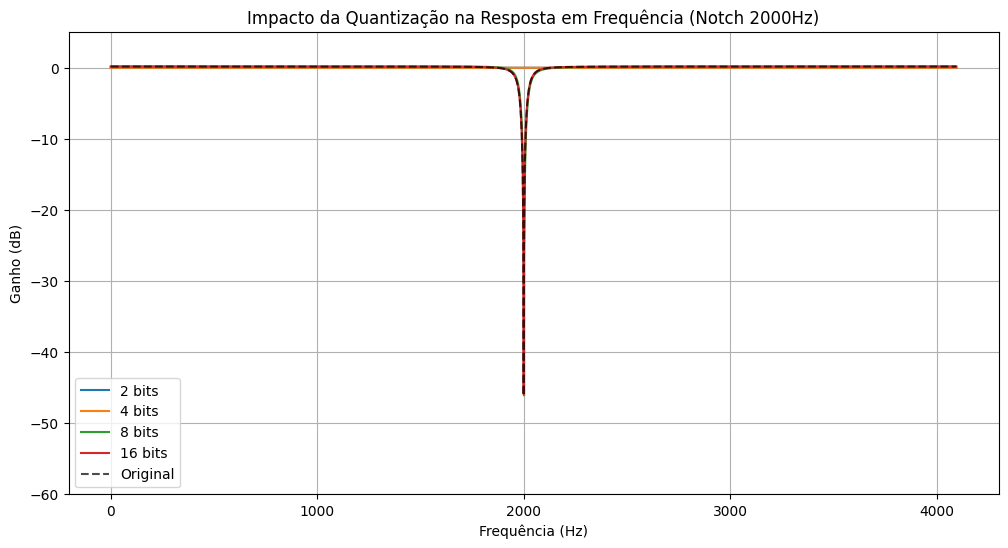

In [12]:
def quantize_coeffs(coeffs, bits):
    max_val = np.max(np.abs(coeffs))
    levels = 2**(bits - 1) - 1
    return np.round((coeffs / max_val) * levels) * (max_val / levels)

bits_list = [2, 4, 8, 16]
plt.figure(figsize=(12, 6))
n_points = 8000

for b in bits_list:
    bq = quantize_coeffs(b2, b)
    aq = quantize_coeffs(a2, b)
    w, h = freqz(bq, aq, worN=n_points)
    plt.plot(0.5*fs*w/np.pi, 20 * np.log10(np.abs(h) + 1e-10), label=f"{b} bits")

_, h_orig = freqz(b2, a2, worN=n_points)
plt.plot(0.5*fs*w/np.pi, 20 * np.log10(np.abs(h_orig) + 1e-10), "k--", label="Original", alpha=0.7)

plt.title("Impacto da Quantização na Resposta em Frequência (Notch 2000Hz)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Ganho (dB)")
plt.legend()
plt.grid(True)
plt.ylim([-60, 5])
plt.show()

**Discussão sobre a Estrutura em Cascata (SOS):**

1. **Estabilidade:** Decompor em seções de 2ª ordem reduz a sensibilidade dos polos à quantização, evitando instabilidade.
2. **Precisão:** Mantém a resposta em frequência mais fiel ao projeto original em hardware de ponto fixo.
3. **Flexibilidade:** Facilita o ajuste individual de cada filtro na cadeia.